In [107]:
#lab1B

In [108]:
#1. Setup and Imports

from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [109]:
#2. Foundations from Part A

class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [110]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [111]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }

def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [112]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        row, col = state
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        for action in MOVES:
        #       a. Compute the neighbour cell.
            dr, dc = MOVES[action]
        #       b. Check that it is in bounds.
            if self.in_bounds((row + dr, col + dc)):
        #       c. Check that it is free.
                if self.is_free((row + dr, col + dc)):
        #       d. If valid, add the action name to legal_actions.
                    legal_actions.append(action)
        # 3. Return legal_actions.
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        row, col = state
        # Hint:
        # dr, dc = MOVES[action]
        dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.
        return 1

class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        s = node.state
        # for each action in problem.ACTIONS(s):
        for action in problem.actions(s):
        #     s_prime <- problem.RESULT(s, action)
              s_prime = problem.result(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
              cost = node.path_cost + problem.action_cost(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
              yield Node(state = s_prime, parent = node, action = action, path_cost = cost )

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [113]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [114]:
#3.  Weighted Terrain
# WeightedGridProblem

class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        row, col = next_state
        # 2. Return self.terrain_costs[row][col].
        return self.terrain_costs[row][col]

In [115]:
#3.1 Self-Check for WeightedGridProblem

wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [116]:
#4. Heuristic Functions
#4.1 Admissibility and Consistency on Our Grid

def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1, c1 = state
    r2, c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    #
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.dist(state,goal)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [117]:
#4.2 Sel-Check for the Heuristics

assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [118]:
#5. The Priority-Queue frontier

class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [119]:
#6. The BestFitSearch Framework

class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""


class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""


    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        frontier = PriorityQueue()
        frontier.push(self.evaluation(node, problem), node)
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        reached = {node.state: node}
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While the frontier is not empty:
        while frontier:
        #       a. pop the node with the lowest f-value.
            node = frontier.pop()
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
            if problem.is_goal(node.state):
              return SearchResult(
                self.algorithm_name,
                "success",
                node,
                nodes_expanded,
                max_frontier_size,
                reached_count=len(reached)
                )
        #       c. increment nodes_expanded.
            nodes_expanded +=1
        #       d. for each child in self.expand(problem, node):
            for child in self.expand(problem, node):
        #             i. if child.state not in reached OR  child.path_cost < reached[child.state].path_cost:
                 if child.state not in reached or child.path_cost < reached[child.state].path_cost:
        #
        #             i. s = child.state
                            s = child.state
        #            ii. if s not in reached OR child.path_cost < reached[s].path_cost:
                            if s not in reached or child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
                                reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
                                frontier.push(self.evaluation(child, problem),child)
        #       e. update max_frontier_size with len(frontier).
                 max_frontier_size = max(max_frontier_size,len(frontier))
        # 6. If the loop ends, return a SearchResult with status "failure"
        #    and solution=None.
        return SearchResult (self.algorithm_name,
                    "failure",
                    None,
                    nodes_expanded,
                    max_frontier_size,
                    reached_count= len(reached),
                )


In [120]:
#7.Greedy Best_First Search

class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)


In [121]:
#8. A*Search

class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)

In [122]:
#9. Uniform-Cost Search as a Special Case

class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [123]:
#10. Weighted A* Search

class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + (self.weight * self.h(node, problem))

In [124]:
#10.1 Self-Check for the Algorithms

check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0],
     [1, 1, 0],
     [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [125]:
#11. Run the Algorithms on the Part A sample Map

sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]
show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


In [126]:
#12. The Turbulence Map: Where Greedy Goes Wrong

turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]
show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


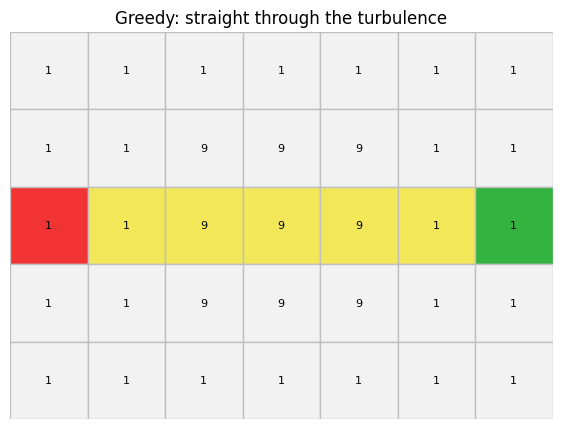

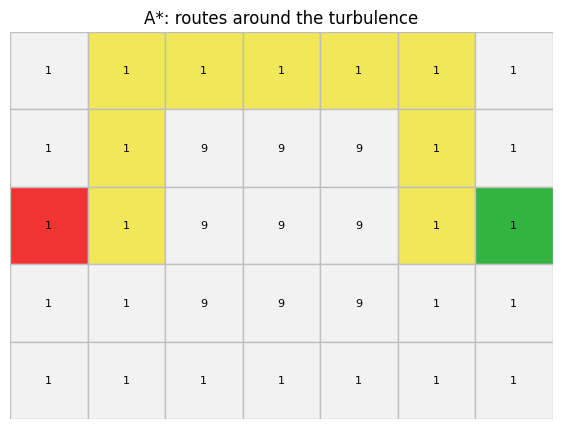

In [127]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [128]:
#13. Experiment: Breaking Admissibility


def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    def h(state, goal):
        return factor * manhattan_distance(state,goal)
    # 2. Return the inner function (do not call it).
    return h
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(
    mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs
)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


In [129]:
# 15. Create Your Own Maps


# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    # Replace this with your own grid.
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0],
    [1,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1],
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0],
    [0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],
    [0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0],
]

custom_costs_1 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0],
    [1,0,0,0,0,0,1,0,0,1,0,1,0,1,0,1],
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0],
    [0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0],
    [1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1],
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0],
    [1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1],
    [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0],
    [0,0,1,0,1,0,0,0,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0],
    [0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,0],
]

custom_start_1 = (0,0)
custom_goal_1 = (11,6)

# Example after completing:
# custom_problem_1 = WeightedGridProblem(
#     custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
# )
custom_problem_1 = WeightedGridProblem(custom_grid_1, custom_start_1,custom_goal_1, terrain_costs=custom_costs_1)
# custom_results_1 = [
#     ucs.search(custom_problem_1),
#     astar.search(custom_problem_1),
#     wastar2.search(custom_problem_1),
#     greedy.search(custom_problem_1),
# ]
custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]
# show_results(custom_results_1)
show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,17,0,121,20,138
1,A*,success,17,0,17,25,42
2,Weighted A* (W=2),success,17,0,17,25,42
3,Greedy,success,17,0,17,25,42


In [130]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    # Replace this with your own grid.
    [0,0,0,0,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0],
    [1,0,0,0,0,0,1,0,0,1,0,1,0,1],
    [0,0,1,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [1,0,0,0,0,1,0,0,0,0,0,0,0,0],
    [0,0,0,0,0,1,0,0,0,0,0,0,1,0],
    [0,0,0,0,0,0,0,0,1,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,0,0,0,1,0,],
]

custom_costs_2 = [
    # Terrain costs (same shape as the grid), if using WeightedGridProblem.
    [0,0,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,0,1,0,0,1,0,0,0,0,0,0,1,0],
    [1,0,0,0,0,0,1,0,0,1,0,1,0,1],
    [0,0,1,0,0,0,0,0,1,0,0,0,0,0],
    [1,0,0,0,0,0,1,1,0,0,0,0,1,0],
    [0,0,0,1,0,0,0,0,0,1,0,0,0,0],
    [1,0,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,0,0,0,0,1,0,0,0,1,0,0,1,0],
    [0,0,1,0,0,0,0,0,1,0,0,0,0,0],
    [0,0,1,0,0,1,0,0,0,1,0,0,1,0],
]

custom_start_2 = (0,1)
custom_goal_2 = (9,13)

# Example after completing:
# custom_problem_2 = WeightedGridProblem(
#     custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
# )
custom_problem_2 = WeightedGridProblem(custom_grid_2, custom_start_2,custom_goal_2, terrain_costs=custom_costs_2)
# custom_results_2 = [
#     ucs.search(custom_problem_2),
#     astar.search(custom_problem_2),
#     wastar2.search(custom_problem_2),
#     greedy.search(custom_problem_2),
# ]
custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]
# show_results(custom_results_2)
show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,21,0,106,17,118
1,A*,success,23,1,27,24,51
2,Weighted A* (W=2),success,23,2,26,24,50
3,Greedy,success,23,2,26,24,50


In [131]:
#16. Reflection Questions

In [132]:
#16.1 Heuristic Functions
#1. h(n) estimates the remaining cost or "distance" needed to reach the goal from the current drone position. Its "knowledge" comes from the problem's geometric or spatial properties like coordinates or grid layout, which are pre-programmed into the heuristic function itself rather than learned from map exploration.

#2. Manhattan distance assumes the drone can travel horizontally and vertically without turning, corners, or physical obstacles. It removes the restriction of collision avoidance (acting as if obstacles do not exist) and simplifies the kinematics by ignoring any complex turning radii or diagonal constraints.

#3. Manhattan distance dominates Euclidean distance. Domination means that for all nodes, (h_{Manhattan}(n) >= h_{Euclidean}(n). Because Manhattan provides a higher (but still admissible) estimate, it is more informed. This predicts that the search algorithm will focus more tightly on the optimal path, resulting in fewer nodes expanded compared to the looser Euclidean estimate.

#4. Admissibility requires that h(n) never overestimates the true minimum cost to the goal. On a basic grid where no diagonal moves are allowed, the minimum possible distance to the goal is exactly the Manhattan distance for instance, traveling at the minimum 1 step per cell cost. If every cell costs more than 1, the true path's cost will be equal to or greater than the unweighted Manhattan estimate, keeping it admissible.
     #If a single step can cost less than 1 ,for instance 0.5, the true shortest path's cost could end up being lower than the Manhattan distance estimate. This would cause h(n) to overestimate the true cost, breaking admissibility. When a heuristic is inadmissible, A* algorithms are no longer guaranteed to find the optimal path


In [133]:
#16.2 Greedy Best-First Search

#1. Greedy ignores the path cost—often denoted as g(n), which is the actual distance or cost accumulated from the start node to the current node.
   # On a turbulence map, the cost is the difficulty, wind resistance, or fuel burned while flying. Because Greedy only looks at how close the drone seems to the destination, it will happily dive straight into a highly turbulent, dangerous zone if that path yields a visually straight or appealing heuristic estimate. As a result, the drone wastes extreme amounts of battery or risks a crash, while an algorithm factoring in g(n) would correctly choose a slightly longer but calmer path.

#2.While Greedy searches faster by evaluating fewer nodes, fewer node expansions do not make it a better algorithm because:
   #-Greedy does not guarantee the shortest, cheapest, or safest path. It can easily lead the drone down a long, winding, or dangerous path simply because each step looked right at the time.
   #-Greedy is technically incomplete. If it enters a dead-end on a complex map, it doesn't have the memory or foresight to back up and try an alternative, meaning it can fail to find a solution entirely

#3.Greedy Best-First Search is perfectly acceptable for a time-critical, short-range drone reconnaissance mission in an open, obstacle-free environment.
 # For instance, a military or search-and-rescue quadcopter that needs to fly straight over an open desert to drop an emergency beacon. There are no mountains, tall buildings, or no-fly zones to maneuver around.
 # In this unobstructed, straight-line space, the straight-line heuristic is incredibly accurate. Because there are no obstacles to mislead the algorithm or force it to take a detour, Greedy will simply fly the shortest geometric distance possible. It will save massive amounts of on-board computing time and battery power compared to running the heavier A* algorithm, while successfully delivering the optimal path.



In [134]:
#16.3 A* Search
#1.In this lab, g(n) is the actual cost the drone has already spent reaching its current location, while h(n) is the estimated remaining cost to reach the goal. Therefore, f(n) represents the estimated total cost of a flight plan from the start to the destination through the current location.
  #For instance, If the drone has already spent a cost of 8 reaching a cell and estimates 4 more units of cost to reach the goal, then: f(n) = 8+4 = 12. A* will prefer routes with smaller estimated total costs.

#2. A* should test for the goal when a node is popped from the priority queue because that is when we know it has the lowest possible cost among all remaining paths.
   #For instance, on a turbulence map, the goal might be generated through a route with high-cost windy cells. If A* immediately accepts that goal when it is generated, it might miss another route that reaches the same goal with a much lower total cost. Waiting until the goal node is popped ensures that A* returns the optimal path.

#3.In BFS, every move has the same cost, so the first time a state is reached is always the cheapest way to reach it. A set is therefore sufficient.
 #In UCS and A*, different paths can reach the same state with different costs. A dictionary allows us to store the best node found so far for each state and replace it if a cheaper path is discovered.
 #For instance, (0,0) -> A -> Goal     cost = 12
 #               (0,0) -> B -> Goal     cost = 8
 #If the goal state was already reached with cost 12, the dictionary lets A* update it when the cheaper cost 8 path is found.

#4. A* usually expands fewer nodes than UCS because the heuristic guides the search toward the goal instead of exploring all low-cost directions equally.
 # For instance, If UCS expands 40 nodes and A* expands only 20 nodes, A* reaches the same optimal solution while doing less work.
 #This gap shows that the heuristic provides useful information about the direction of the goal, making the search more efficient. The more informative the heuristic, the fewer unnecessary nodes A* typically expands.


In [135]:
#16.4 Admissibility and Consistency

#1. A heuristic is admissible if it never overestimates the true minimum cost to reach the goal.
 #h(n) <= true cost from n to goal
 #A heuristic is consistent if, for every move from a state n to a neighboring state n', it satisfies:
 #h(n) <= c(n,a,a') + h(n')
 #This means the estimated cost should not decrease by more than the actual cost of taking one step.
 #Relationship:
 #A consistent heuristic is always admissible. However, an admissible heuristic is not necessarily consistent.

 #2.The experiment showed that when a heuristic overestimates the true cost, A* is no longer guaranteed to find the optimal solution.
  #For instance, If the heuristic makes some paths appear much more expensive than they really are, A* may ignore the best route and choose a more costly one instead. This confirms the lecture's claim that A*'s optimality depends on using an admissible heuristic.

 #3. Yes. Manhattan distance is consistent on a unit-cost grid.
   #Consider for instance n  = (0,0), n' = (0,1), and goal = (2,2), Manhattan distances:h(0,0) = |0-2| + |0-2| = 4, h(0,1) = |0-2| + |1-2| = 3
   #The cost of one move is:c(n,a,n') = 1. checking consistency: h(n) ≤ c(n,a,n') + h(n'), 4 ≤ 1 + 3, 4 ≤ 4. The inequality holds.On a unit-cost grid, moving one step changes the Manhattan distance by at most 1, so the consistency condition is always satisfied.
   #Therefore, Manhattan distance is a consistent heuristic for our grid-search problem.

In [136]:
# 16.5 Weighted A* and Trade-offs

#1. Weighted A* uses: f(n) = g(n) + w * h(n), where:
#g(n) = cost already spent reaching the node.
#h(n) = estimated cost to the goal.
#w = weight applied to the heuristic.
#For instance:
#w=0 -> f(n)=g(n) -> behaves like Uniform Cost Search (UCS).
#w=1 -> f(n)=g(n)+h(n) -> standard A*.
#Large w -> heuristic dominates the decision -> behaves more like Greedy Best-First Search.
#As w increases, the search becomes faster and more goal-directed, but the solution may become less optimal.

#2. Weighted A* guarantees that the solution cost will be at most w times the optimal cost, assuming the heuristic is admissible.
#Solution Cost <= w * Optimal Cost
#For instance, If the optimal path cost is 20 and w=2: Solution Cost <= 40
#In our experiments, the solutions found by Weighted A* were usually much closer to the optimal cost than the worst-case bound predicts.
#The bound is a guarantee, not a typical outcome, so the observed solutions often stayed well within it.

#3.I would choose Weighted A* with a moderate weight such as: w = 1.5 or w = 2
 #This choice balances speed and solution quality.
 #Reasoning:-UCS may spend too much time exploring unnecessary states.
           #-A* is optimal but may still expand many nodes.
           #-Weighted A* with w>1 explores fewer nodes and reaches a solution faster.
           #-A very large w behaves like Greedy Search and may produce a poor route.

#For a drone with limited battery margin and a slow onboard computer, a moderate weight provides a good compromise between finding a low-cost route and reducing computation time.

In [137]:
#16.6 Memory and Real_World Drone Context

#1.A* uses a priority queue (frontier) and a reached dictionary to store generated nodes.
 #As the search space grows, these structures can consume a large amount of memory because many states must remain stored at the same time.
 #IDA* avoids this problem by using depth-first search with an increasing cost limit, so it mainly stores the current path rather than all generated nodes. This greatly reduces memory usage.
 #Trade-off: IDA* uses less memory but spends more time because it repeatedly searches from the start with larger limits and may revisit the same states many times.

#2. In our lab, terrain costs are simple numbers assigned to grid cells. In a real drone application, the cost could include:
  #-Wind speed and direction.
  #-Weather forecasts (rain, storms, fog).
  #-Battery consumption.
  #-Temporary no-fly zones.
  #-Building heights and obstacles.
  #-Air traffic from other drones.
  #-Signal strength and communication coverage.
  #-Safety risks in populated areas.

#3. Our heuristic estimates the cost to a fixed goal location. If the target moves, the heuristic may become inaccurate because the goal position changes while the drone is searching.

#4. I would choose A* with the Manhattan-distance heuristic because it balances efficiency and solution quality. It usually expands far fewer nodes than UCS while still finding an optimal path when the heuristic is admissible.
#For instance:For a drone navigating a known map with fixed obstacles and terrain costs, A* provides a good combination of speed and route quality.